Step 1

In [3]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Writing myode.py


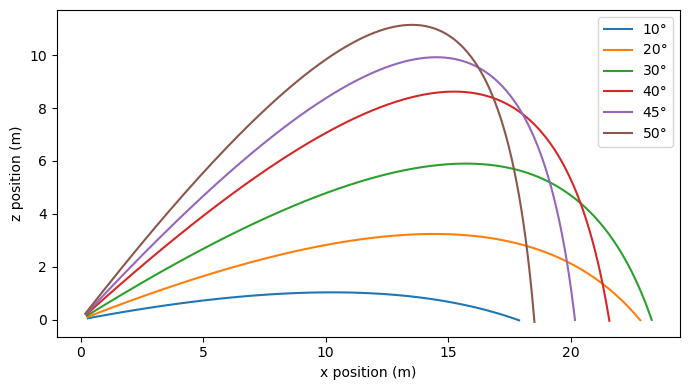

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import myode

g = 9.8
b = 1.0   # drag coefficient (1/s)
speed = 30.0  # launch speed (m/s)

# --- Define equations of motion ---
def diffeq(y):
    xpos, xvel, zpos, zvel = y
    xacc = -b*xvel  # horizontal: drag only
    zacc = -g - b*zvel  # vertical: gravity + drag
    return np.array([xvel, xacc, zvel, zacc])

# --- Simulate one trajectory and return landing x-position ---
def final_x(angle_deg, dt=0.01):
    """Run projectile from origin at given launch angle; return x at landing."""
    angle = np.radians(angle_deg)
    y = np.array([0.0, speed*np.cos(angle), 0.0, speed*np.sin(angle)])
    while y[2] >= 0  :            # TODO: condition to keep simulating
        y = myode.move_RK2(diffeq, y, dt)
    return y[0]             # TODO: return landing x-position



# --- Plot trajectories for a few angles to visualize ---
fig, ax = plt.subplots(figsize=(7, 4))
for angle_deg in [10, 20, 30, 40, 45, 50]:    # TODO: choose a few angles to plot
    angle = np.radians(angle_deg)
    y = np.array([0.0, speed*np.cos(angle), 0.0, speed*np.sin(angle)])
    xs, zs = [], []
    while y[2] >= 0:
        y = myode.move_RK2(diffeq, y, dt=0.01)
        xs.append(y[0]); zs.append(y[2])
    ax.plot(xs, zs, label=f'{angle_deg}°')
ax.set_xlabel('x position (m)')
ax.set_ylabel('z position (m)')
ax.legend()
plt.tight_layout()
plt.show()


Step 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import myode

g = 9.8
b = 1.0   # drag coefficient (1/s)
speed = 30.0  # launch speed (m/s)

# --- Define equations of motion ---
def diffeq(y):
    xpos, xvel, zpos, zvel = y
    xacc = -b*xvel  # horizontal: drag only
    zacc = -g - b*zvel  # vertical: gravity + drag
    return np.array([xvel, xacc, zvel, zacc])

# --- Simulate one trajectory and return landing x-position ---
def final_x(angle_deg, dt=0.01):
    """Run projectile from origin at given launch angle; return x at landing."""
    angle = np.radians(angle_deg)
    y = np.array([0.0, speed*np.cos(angle), 0.0, speed*np.sin(angle)])
    while y[2] >= 0  :            # TODO: condition to keep simulating
        y = myode.move_RK2(diffeq, y, dt)
    return y[0]             # TODO: return landing x-position

best_angle_target = 0
best_x_target = 0
smallest_error = None

for angle in np.arange(1, 90, 1):
    landing_x = final_x(angle)
    error = abs(landing_x - 20.0)

    if smallest_error is None or error < smallest_error:
        smallest_error = error
        best_angle_target = angle
        best_x_target = landing_x

print(f"target 20m: launch at {best_angle_target} degrees (Lands at {best_x_target:.3f}m).")

target 20m: launch at 13 degrees (Lands at 20.067m).


Step 3

Maximum Range: 23.458 m achieved at 26 degrees


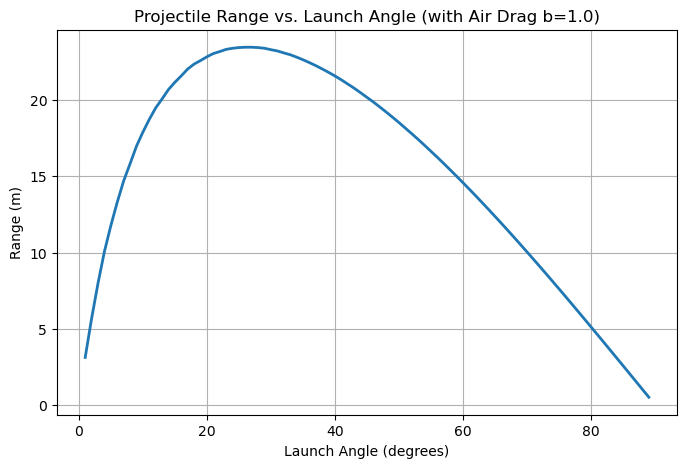

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import myode

g = 9.8
b = 1.0   # drag coefficient (1/s)
speed = 30.0  # launch speed (m/s)

# --- Define equations of motion ---
def diffeq(y):
    xpos, xvel, zpos, zvel = y
    xacc = -b*xvel  # horizontal: drag only
    zacc = -g - b*zvel  # vertical: gravity + drag
    return np.array([xvel, xacc, zvel, zacc])

# --- Simulate one trajectory and return landing x-position ---
def final_x(angle_deg, dt=0.01):
    """Run projectile from origin at given launch angle; return x at landing."""
    angle = np.radians(angle_deg)
    y = np.array([0.0, speed*np.cos(angle), 0.0, speed*np.sin(angle)])
    while y[2] >= 0  :            # TODO: condition to keep simulating
        y = myode.move_RK2(diffeq, y, dt)
    return y[0]             # TODO: return landing x-position

angles = np.arange(1, 90, 1)
ranges = []


for angle in angles:
    ranges.append(final_x(angle))

max_range = max(ranges)


best_index = ranges.index(max_range)
best_angle_max = angles[best_index]

print(f"Maximum Range: {max_range:.3f} m achieved at {best_angle_max} degrees")

plt.figure(figsize=(8, 5))
plt.plot(angles, ranges, linewidth=2)
plt.title("Projectile Range vs. Launch Angle (with Air Drag b=1.0)")
plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Range (m)")
plt.grid(True)
plt.show()

Step 4

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import myode

g = 9.8
b = 1.0   # drag coefficient (1/s)
speed = 30.0  # launch speed (m/s)

# --- Define equations of motion ---
def diffeq(y):
    xpos, xvel, zpos, zvel = y
    xacc = -b*xvel  # horizontal: drag only
    zacc = -g - b*zvel  # vertical: gravity + drag
    return np.array([xvel, xacc, zvel, zacc])

# --- Simulate one trajectory and return landing x-position ---
def final_x(angle_deg, dt=0.01):
    """Run projectile from origin at given launch angle; return x at landing."""
    angle = np.radians(angle_deg)
    y = np.array([0.0, speed*np.cos(angle), 0.0, speed*np.sin(angle)])
    while y[2] >= 0  :            # TODO: condition to keep simulating
        y = myode.move_RK2(diffeq, y, dt)
    return y[0]             # TODO: return landing x-position


b_values = [0, 0.5, 1.0, 2.0]
angles = np.arange(1,90,1)

for test_b in b_values:
    b= test_b
    ranges = []

    for angle in angles:
        ranges.append(final_x(angle))

    max_range = max(ranges)
    best_angle = angles[ranges.index(max_range)]
    print(f"Optimal Angle: {best_angle} degrees, Drag coefficient is {test_b}, ")


Optimal Angle: 44 degrees, Drag coefficient is 0, 
Optimal Angle: 33 degrees, Drag coefficient is 0.5, 
Optimal Angle: 26 degrees, Drag coefficient is 1.0, 
Optimal Angle: 20 degrees, Drag coefficient is 2.0, 


The optimal angle is 26 degrees. This is far off from the 45 degree angle for drag free physics. This is because the drag slows the object down as it travel through the air reducing all the velocities of the object. Now as the drag velocities increase the rate at which the velocities decrease increases cause the angle to decrease as the drag increases.